# Частина третя: Аналіз датасет c Kaggle.com

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

- Прочитайте csv файл (використовуйте функцію read_csv)
- Виведіть перші п'ять рядків (використовується функція head)
- Виведіть розміри датасету (використовуйте атрибут shape)
- Про скільки книг зберігає дані датасет? Відповідь: Про 351.

In [2]:
df = pd.read_csv("bestsellers_with_categories.csv")
print(f"shape = {df.shape}")
print(f"Unique books = {len(df[['Name', 'Author']].drop_duplicates())}")
df.head()

shape = (550, 7)
Unique books = 351


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [3]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head(2)

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction


## Первинне дослідження даних

- Перевірте, чи у всіх рядків вистачає даних: виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)
- Чи є в якихось змінних пропуски? Відповідь: Ні

In [4]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

- Перевірте, які є унікальні значення в колонці genre (використовуйте функцію unique)
- Які є унікальні жанри? Відповідь: 'Non Fiction', 'Fiction'

In [5]:
df['genre'].unique()

<StringArray>
['Non Fiction', 'Fiction']
Length: 2, dtype: str

Тепер подивіться на розподіл цін: побудуйте діаграму (використовуйте kind='hist')

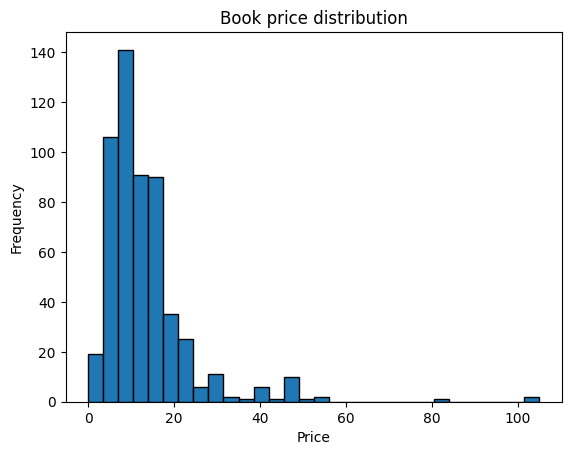

In [6]:
df['price'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Book price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [7]:
print(f"Відповідь: max price = {df['price'].max()}")
print(f"Відповідь: min price = {df['price'].min()}")
print(f"Відповідь: mean price = {df['price'].mean()}")
print(f"Відповідь: median price = {df['price'].median()}")

Відповідь: max price = 105
Відповідь: min price = 0
Відповідь: mean price = 13.1
Відповідь: median price = 11.0


## Пошук та сортування даних

Який рейтинг у датасеті найвищий?

In [8]:
max_rating = df['user_rating'].max()
print(f"Відповідь: max rating = {max_rating}")

Відповідь: max rating = 4.9


Скільки книг мають такий рейтинг?

In [9]:
print(f"Відповідь: qty of books with rating = {max_rating} is {len(df[df['user_rating']==max_rating])}")

Відповідь: qty of books with rating = 4.9 is 52


Яка книга має найбільше відгуків?

In [10]:
max_reviews = df['reviews'].max()
print(f"Відповідь: max qty of reviews = '{df.loc[df['reviews'] == max_reviews, 'name'].tolist()[0]}'")

Відповідь: max qty of reviews = 'Where the Crawdads Sing'


##### З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

Відповідь 1: Since the dataset is for "bestselling" books and we are asked for "top 50", we need to analyze the rating. Since the quantity of reviews is different, we need to weight that value (weighted average)

## Bayesian average (weighted average) - notes for myself
$$W = \frac{R * v + C * m}{v+m},\space where$$
- $W$: Weighted Rating (the final score we use to rank).
- $R$: Average rating for the book
- $v$: Number of reviews for the book.
- $m$: Minimum reviews required to be listed in the top chart (a "threshold").
- $C$: The mean rating across the whole dataset (the "global average").

Logic behind the formula:
- we could just go with $R*v$ (which would rather mean "the most discussed book"), but if $v$ is very large, $m$, becomes insignificant. Adding $C*m$ accounts for that.
- if $v$ is very small, $v$ becomes insignificant, but the $R*v$ term saves it.

In [11]:
global_average_rating = df['user_rating'].mean()
top_threshold = df['reviews'].median()              # Minimum reviews required to be listed in the top chart (a "threshold"). Mean is prone to outliers so using median instead

df['weighted_rating'] = (df['user_rating'] * df['reviews'] + global_average_rating * top_threshold) / (df['reviews'] + top_threshold)
df_2015_top_50 = df[df['year'] == 2015].sort_values(by="weighted_rating", ascending=False)[:50] # sorting from highest to lowest rating
print(f"Відповідь 2: the most expensive book of 2015 that is also of highest value to customers (the so-called 'top') is '{df_2015_top_50.loc[df_2015_top_50['price'] == df_2015_top_50['price'].max(), 'name'].tolist()[0]}'")

Відповідь 2: the most expensive book of 2015 that is also of highest value to customers (the so-called 'top') is 'Publication Manual of the American Psychological Association, 6th Edition'


Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [12]:
df_2010_top_50 = df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].sort_values(by="weighted_rating", ascending=False)[:50]
print(f"Відповідь: top 50 fiction books of 2010 = {len(df_2010_top_50)} books")

Відповідь: top 50 fiction books of 2010 = 20 books


Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?

In [13]:
df_2010_2011 = df[(df['year'] == 2010) | (df['year'] == 2011)]
print(f"Відповідь: books with rating == '4.9' in 2010-2011: {len(df_2010_2011[df_2010_2011['user_rating'] == 4.9])} books")

Відповідь: books with rating == '4.9' in 2010-2011: 1 books


І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).

In [14]:
df_2015_lt_8_usd_sorted = df[(df['year'] == 2015) & df['price'] < 8.0].sort_values(by="price")
print("df_2015_lt_8_usd_sorted.head():")
display(df_2015_lt_8_usd_sorted.head())

df_2015_lt_8_usd_sorted.head():


,name,author,user_rating,reviews,price,year,genre,weighted_rating
42,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,4.8,4505,0,2011,Fiction,4.680899
461,The Short Second Life of Bree Tanner: An Eclip...,Stephenie Meyer,4.6,2122,0,2010,Fiction,4.614722
71,"Diary of a Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,4.8,6812,0,2013,Fiction,4.698750
381,The Getaway,Jeff Kinney,4.8,5836,0,2017,Fiction,4.691895
116,Frozen (Little Golden Book),RH Disney,4.7,3642,0,2014,Fiction,4.642690


Яка книга остання у відсортованому списку?

In [15]:
print(f"Відповідь: the last book in the sorted df: '{df_2015_lt_8_usd_sorted[-1:]['name'].tolist()[0]}'")

Відповідь: the last book in the sorted df: 'Diagnostic and Statistical Manual of Mental Disorders, 5th Edition: DSM-5'


## Агрегування даних та з'єднання таблиць

Для початку давайте подивимося на максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Не беріть усі стовпці, виберіть тільки потрібні вам

In [16]:
df.groupby(by="genre").agg(['min', 'max'])['price']

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


- Максимальна ціна для жанру Fiction: 82
- Мінімальна ціна для жанру Fiction: 0
- Максимальна ціна для жанру Non Fiction: 105
- Мінімальна ціна для жанру Non Fiction: 0

Тепер створіть новий датафрейм, який вміщатиме кількість книг для кожного з авторів (використовуйте функції groupby та agg, для підрахунку кількості використовуйте count). Не беріть усі стовпці, виберете тільки потрібні

In [17]:
df_grouped_by_author_by_name = df.groupby(by='author').agg(
    author_count=('name', 'count'),
)
df_grouped_by_author_by_name

,author_count
author,
Abraham Verghese,2
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,3
William Davis,2
William P. Young,2


Якої розмірності вийшла таблиця? Відповідь: (248, 1)

In [18]:
df_grouped_by_author_by_name.shape

(248, 1)

- Який автор має найбільше книг? Відповідь: Jeff Kinney
- Скільки книг цього автора? Відповідь: 12

In [19]:
df_grouped_by_author_by_name.sort_values(by='author_count', ascending=False)

,author_count
author,
Jeff Kinney,12
Gary Chapman,11
Rick Riordan,11
Suzanne Collins,11
American Psychological Association,10
...,...
Thomas Piketty,1
The Washington Post,1
Tina Fey,1


Тепер створіть другий датафрейм, який буде вміщати середній рейтинг для кожного автора (використовуйте функції groupby та agg, для підрахунку середнього значення використовуйте mean). Не беріть усі стовпці, виберете тільки потрібні

In [20]:
df_grouped_by_author_by_rating = df.groupby(by='author').agg(
    rating_avg=('user_rating', 'mean'),
)
df_grouped_by_author_by_rating

,rating_avg
author,
Abraham Verghese,4.600000
Adam Gasiewski,4.400000
Adam Mansbach,4.800000
Adir Levy,4.800000
Admiral William H. McRaven,4.700000
...,...
Walter Isaacson,4.566667
William Davis,4.400000
William P. Young,4.600000


- У якого автора середній рейтинг мінімальний? Відповідь: Donna Tartt
- Який у цього автора середній рейтинг? Відповідь: 3.9

In [21]:
df_grouped_by_author_by_rating.sort_values(by='rating_avg')

,rating_avg
author,
Donna Tartt,3.9
Gallup,4.0
Gillian Flynn,4.0
Muriel Barbery,4.0
Ian K. Smith M.D.,4.1
...,...
Lin-Manuel Miranda,4.9
Patrick Thorpe,4.9
Sarah Young,4.9


- З'єднайте останні два датафрейми так, щоб для кожного автора було видно кількість книг та середній рейтинг (Використовуйте функцію concat з параметром axis=1). Збережіть результат у змінну
- Відсортуйте датафрейм за зростаючою кількістю книг та зростаючим рейтингом (використовуйте функцію sort_values)

In [22]:
df_by_author = pd.concat([df_grouped_by_author_by_name, df_grouped_by_author_by_rating], axis=1).sort_values(by=['author_count', 'rating_avg'])
df_by_author

,author_count,rating_avg
author,,
Muriel Barbery,1,4.000000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Pierre Dukan,1,4.100000
Elizabeth Strout,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


Який автор перший у списку? Muriel Barbery

In [23]:
df_by_author.iloc[0].name

'Muriel Barbery'

## Додайте від 3 до 5 графіків функцій різного типу на ваш вибір. Задайте графікам оформлення, щоб кожен графік у своїй домашній роботі чимось відрізнявся і не був схожим на інші. Можна використовувати як matplotlib, так і seaborn.

In [58]:
top_authors_df = df.groupby(by='author').agg(
    avg_weighted_rating=('weighted_rating', 'mean'),
    book_count=('name', 'count'),
).sort_values(by="avg_weighted_rating", ascending=False)

top_20_authors_df = top_authors_df.head(20)
top_20_authors_df.head()

,avg_weighted_rating,book_count
author,,
Sarah Young,4.814177,6
Eric Carle,4.814085,7
Dr. Seuss,4.799709,9
Bill Martin Jr.,4.794589,2
Delia Owens,4.783837,1


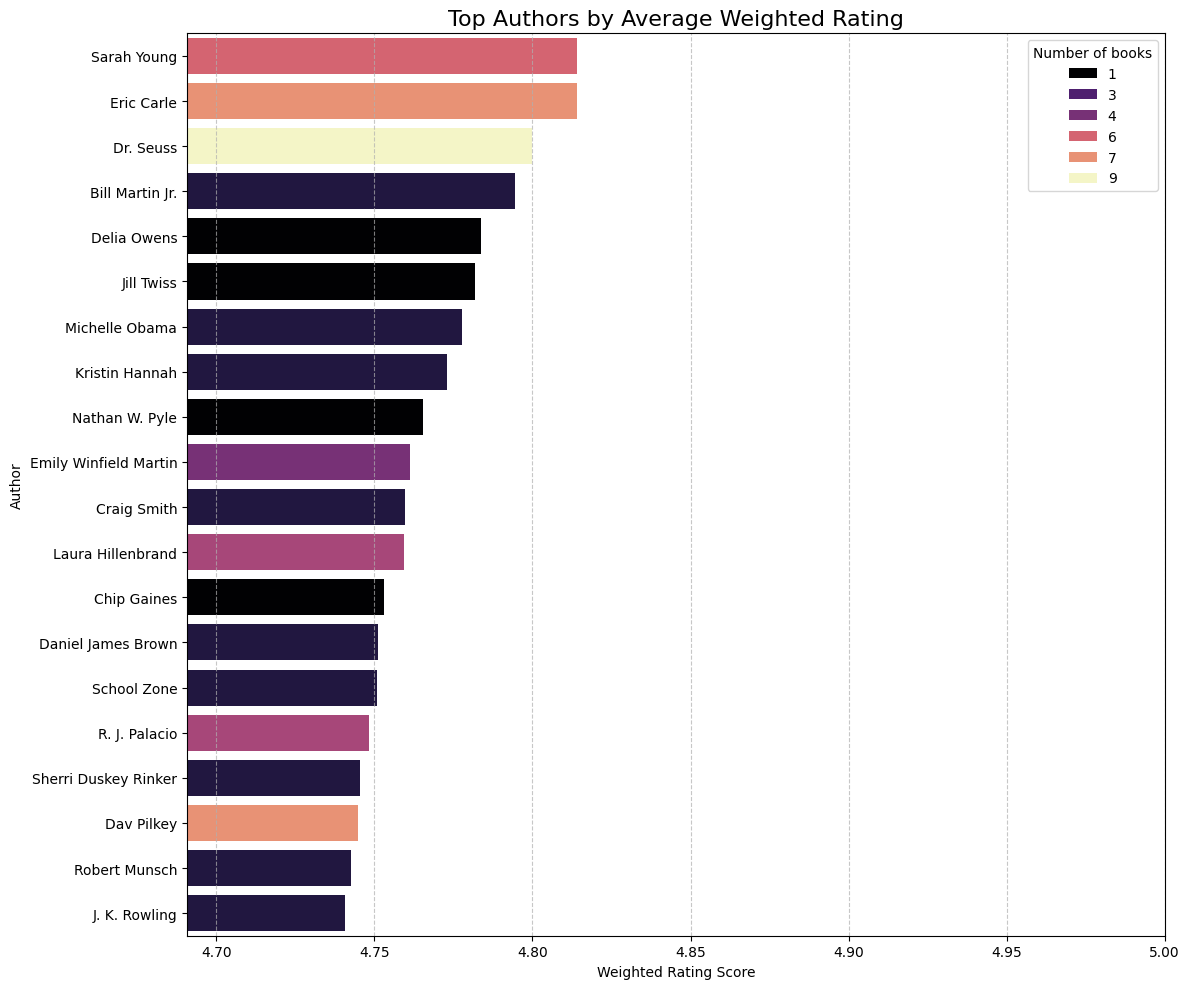

In [50]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=top_20_authors_df,
    x='avg_weighted_rating',
    y=top_20_authors_df.index,
    palette='magma',
    hue='book_count',
    dodge=False,       # Keeps bars centered on the y-axis ticks
)
# Zoom in on the scale. Since ratings usually range from 4.0 to 5.0,
# starting at 0 makes bars look identical.
plt.xlim(top_20_authors_df['avg_weighted_rating'].min() - 0.05, 5.0)
plt.title('Top Authors by Average Weighted Rating', fontsize=16)
plt.xlabel('Weighted Rating Score')
plt.ylabel('Author')
plt.legend(title='Number of books', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

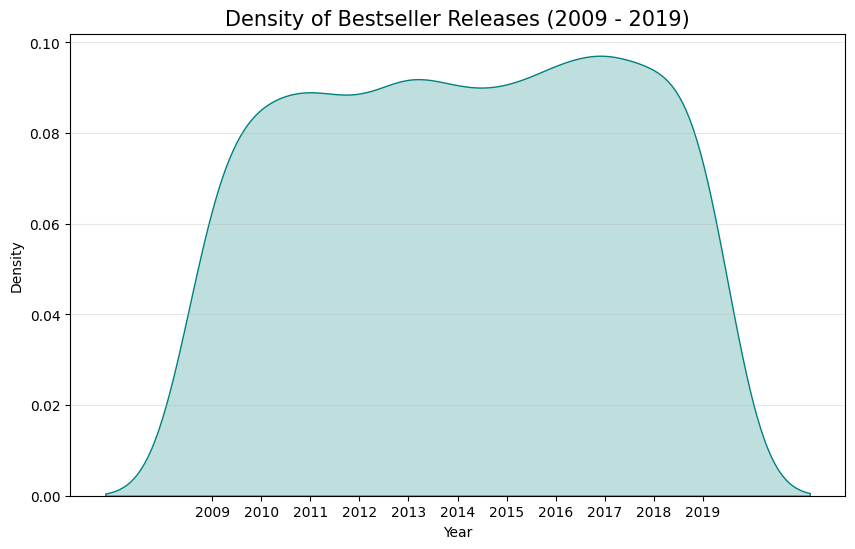

In [62]:
top_authors_df_by_year = df.groupby(by=['author', 'year']).agg(
    avg_weighted_rating=('weighted_rating', 'mean'),
    book_count=('name', 'count'),
).sort_values(by="book_count", ascending=False)

plt.figure(figsize=(10, 6))

sns.kdeplot(data=top_authors_df_by_year, x='year', fill=True, color='teal', bw_adjust=0.8)

plt.title('Density of Bestseller Releases (2009 - 2019)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Density')
plt.xticks(range(df['year'].min(), df['year'].max() + 1)) # Ensure every year shows up
plt.grid(axis='y', alpha=0.3)

plt.show()

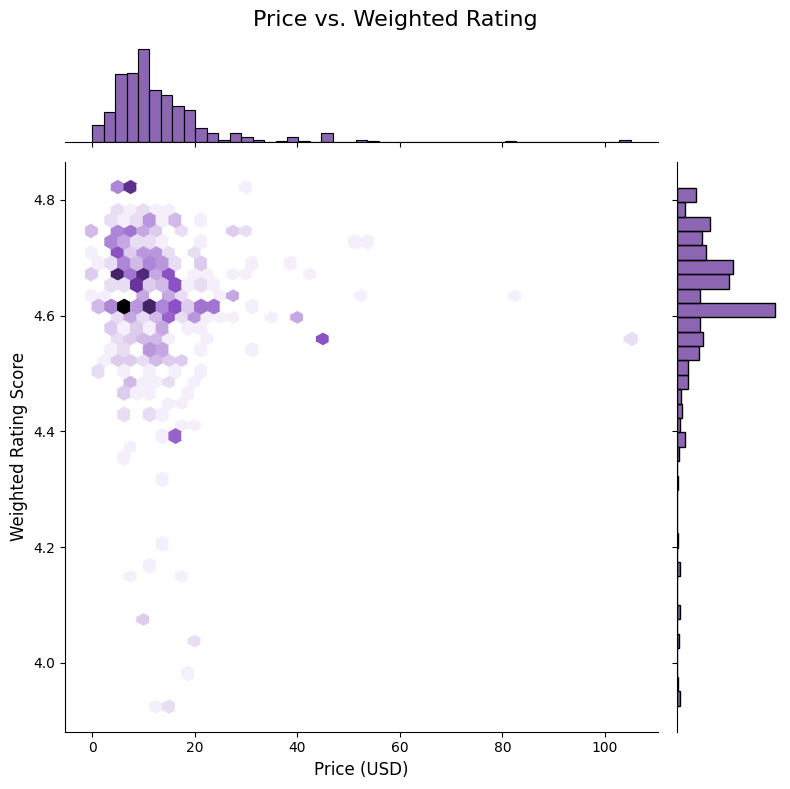

In [ ]:
g = sns.jointplot(
    data=df,
    x='price',
    y='weighted_rating',
    kind='hex',
    color='rebeccapurple',
    height=8,
)

# Adding a title requires accessing the underlying figure
g.fig.suptitle('Price vs. Weighted Rating', fontsize=16)
g.set_axis_labels('Price (USD)', 'Weighted Rating Score', fontsize=12)

plt.tight_layout()
plt.show()